In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

def obtenerEstadisticas(nombreArchivo):
    dataset = pd.read_csv(nombreArchivo)
    # ID,MSE,PSNR_dB,SSIM

    Max_MSE = max(dataset["MSE"])
    Max_SSIM = max(dataset["SSIM"])
    Max_PSNR = max(dataset["PSNR_dB"])
    Min_PSNR = min(dataset["PSNR_dB"])
    Min_MSE = min(dataset["MSE"])
    Min_SSIM = min(dataset["SSIM"])
    Prom_SSIM = dataset["SSIM"].mean()
    Prom_PSNR = dataset["PSNR_dB"].mean()
    Prom_MSE = dataset["MSE"].mean()

    data = {
        'Métrica': ['Promedio', 'Máximo', 'Mínimo'],
        'MSE': [Prom_MSE, Max_MSE, Min_MSE ],
        'PSNR_dB': [Prom_PSNR, Max_PSNR,Min_PSNR ],
        'SSIM': [Prom_SSIM,Max_SSIM,Min_SSIM]
    }
    df_ancho = pd.DataFrame(data)
    print(df_ancho)
    return df_ancho


In [53]:
Continuum100p2 = obtenerEstadisticas("Dataset Joaquin.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.004451  26.755838  0.673906
1    Máximo  0.040891  35.739901  0.869659
2    Mínimo  0.000267  13.883702  0.316443


In [54]:
Chromosfera100p2 = obtenerEstadisticas("Dataset Benjamin.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.004065  25.032789  0.758701
1    Máximo  0.022116  30.974167  0.873365
2    Mínimo  0.000799  16.552987  0.307285


In [55]:
Chromosfera100p1 = obtenerEstadisticas("Dataset Jose.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.005867  23.411941  0.683601
1    Máximo  0.019901  30.509045  0.847252
2    Mínimo  0.000889  17.011154  0.361159


In [57]:
Continuum100p1= obtenerEstadisticas("Dataset Nayely.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.002390  29.012113  0.701866
1    Máximo  0.024522  36.757098  0.887417
2    Mínimo  0.000211  16.104353  0.362464


In [58]:
Chromosfera200p = obtenerEstadisticas("Dataset Extra.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.007520  27.658908  0.764239
1    Máximo  0.284833  34.178554  0.896743
2    Mínimo  0.000382   5.454090  0.348002


In [81]:
def crearGraficos(Metrica):
    datasets = ['Chromosfera 100p-1','Chromosfera 100p-2','Chromosfera 200p','Continuum100p-1','Continuum100p-2']

    ssim_min  = [Chromosfera100p1[Metrica][2], 
                 Chromosfera100p2[Metrica][2], 
                 Chromosfera200p[Metrica][2], 
                 Continuum100p1[Metrica][2], 
                 Continuum100p2[Metrica][2]]

    ssim_mean = [Chromosfera100p1[Metrica][0], 
                 Chromosfera100p2[Metrica][0],
                 Chromosfera200p[Metrica][0], 
                 Continuum100p1[Metrica][0], 
                 Continuum100p2[Metrica][0]]
    
    ssim_max  = [Chromosfera100p1[Metrica][1], 
                 Chromosfera100p2[Metrica][1],
                 Chromosfera200p[Metrica][1], 
                 Continuum100p1[Metrica][1], 
                 Continuum100p2[Metrica][1]]

    x = np.arange(len(datasets))
    width = 0.15
    plt.figure(figsize=(10,5))
    bars_min = plt.bar(x - width, ssim_min, width, label='Min')
    bars_mean = plt.bar(x, ssim_mean, width, label='Promedio')
    bars_max = plt.bar(x + width, ssim_max, width, label='Max')
    plt.bar_label(bars_min, fmt='%.4f')
    plt.bar_label(bars_mean, fmt='%.4f')
    plt.bar_label(bars_max, fmt='%.4f')
    if Metrica == "MSE":
        plt.yscale('log')
    plt.xticks(x, datasets)
    plt.ylabel(Metrica)
    plt.title(f"{Metrica} por dataset")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

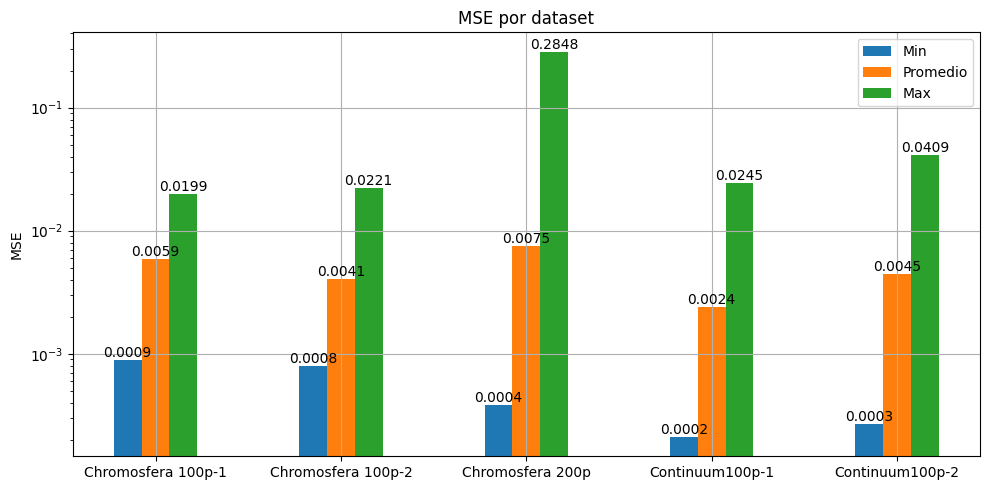

In [82]:
crearGraficos("MSE")

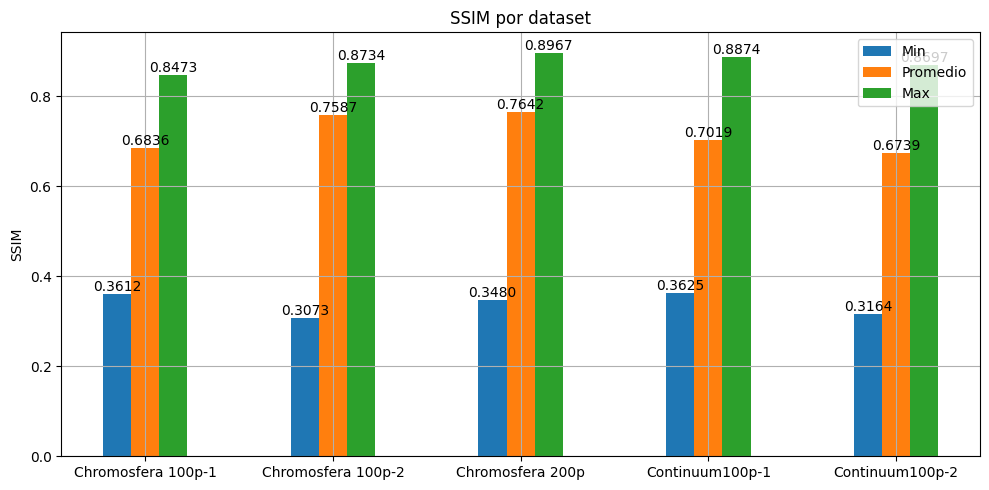

In [83]:
crearGraficos("SSIM")

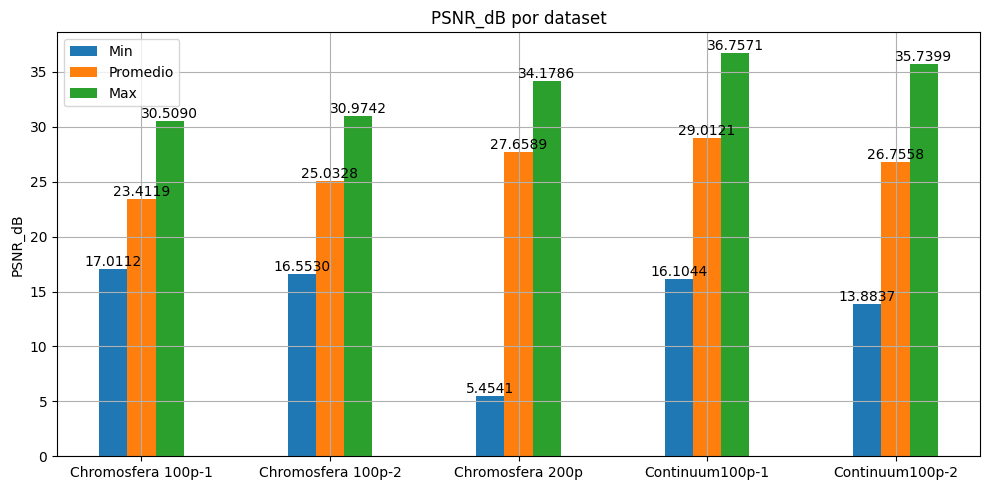

In [84]:
crearGraficos("PSNR_dB")